# 02 – EDA: CMS Medicare Geographic Variation (2014–2024)
**Input:** `data/clean/county.csv`, `data/clean/state.csv`, `data/clean/national.csv`
**Output:** Exploratory analysis of national, state and county data in `notebooks/analysis/`

## 1. Importing libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%pip install plotly
import plotly.express as px
%pip install "nbformat>=4.2"

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


## 2. Converting cleaned csv files into dataframe
and briefly checking if it is working

In [2]:
national_df = pd.read_csv(
    "../data/clean/national_clean.csv",
    dtype={"fips": str}
)

state_df = pd.read_csv(
    "../data/clean/state_clean.csv",
    dtype={"fips": str}
)

county_df = pd.read_csv(
    "../data/clean/county_clean.csv",
    dtype={"fips": str}
)

In [3]:
# Checking the top 2 rows of each dataframe
display (national_df.head(2))
display (state_df.head(2))
display (county_df.head(2))

,year,name,fips,benes_total,benes_om,ma_rate_pct,avg_age,female_pct,medicaid_pct,spend_pc_actual,spend_pc_std,ip_spend_pc_std,ip_share_pct,ip_stays_per_1000,ip_users_pct,readmit_rate_pct,ed_visits_per_1000
0,2014,National,NaN,56767775.0,33462969.0,32.13,71.0,55.05,21.48,9767.0,9191.0,2620.0,28.51,281.7,17.50,18.08,670.72
1,2015,National,NaN,58294174.0,33551396.0,33.92,71.0,54.94,20.95,9959.0,9455.0,2644.0,27.96,278.6,17.36,17.97,682.52


,year,name,fips,benes_total,benes_om,ma_rate_pct,avg_age,female_pct,medicaid_pct,spend_pc_actual,spend_pc_std,ip_spend_pc_std,ip_share_pct,ip_stays_per_1000,ip_users_pct,readmit_rate_pct,ed_visits_per_1000
0,2014,AK,02,84573.0,71383.0,0.66,70.0,50.32,23.81,8602.0,6524.0,2114.0,32.40,194.81,13.60,13.71,555.31
1,2014,AL,01,994352.0,674129.0,24.99,70.0,55.83,20.95,8655.0,9365.0,2657.0,28.37,295.38,18.58,17.17,685.01


,year,name,fips,benes_total,benes_om,ma_rate_pct,avg_age,female_pct,medicaid_pct,spend_pc_actual,spend_pc_std,ip_spend_pc_std,ip_share_pct,ip_stays_per_1000,ip_users_pct,readmit_rate_pct,ed_visits_per_1000,rucc_code,rural_urban
0,2014,AK-Aleutians East,02013,168.0,117.0,NaN,71.0,43.59,23.08,6076.0,4577.0,1366.0,29.84,153.85,11.11,NaN,196.58,9.0,Rural
1,2014,AK-Aleutians West,02016,231.0,136.0,0.0,69.0,47.79,27.21,13251.0,9712.0,3305.0,34.03,205.88,16.91,NaN,198.53,9.0,Rural


## 3. Medicare Spending Across Places, 2014–2024
Missing spending values of some counties are automatically excluded

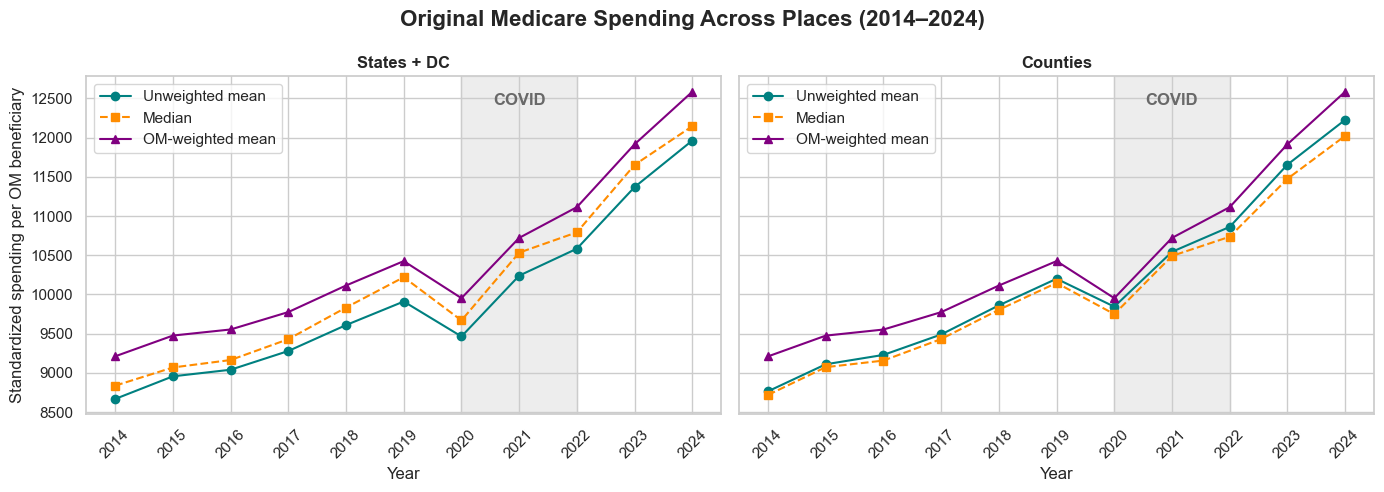

In [4]:
# Calculate the unweighted mean and median across places
state_summary = state_df.groupby("year")["spend_pc_std"].agg(
    ["mean", "median"]
).reset_index()

county_summary = county_df.groupby("year")["spend_pc_std"].agg(
    ["mean", "median"]
).reset_index()

# Keep rows with both spending and Original Medicare counts available
state_weighted = state_df.dropna(
    subset=["spend_pc_std", "benes_om"]
).copy()

county_weighted = county_df.dropna(
    subset=["spend_pc_std", "benes_om"]
).copy()

# Multiply spending per beneficiary by the Original Medicare count
state_weighted["weighted_spending"] = (
    state_weighted["spend_pc_std"] * state_weighted["benes_om"]
)

county_weighted["weighted_spending"] = (
    county_weighted["spend_pc_std"] * county_weighted["benes_om"]
)

# Sum the weighted spending and matching beneficiary counts by year
state_totals = state_weighted.groupby("year")[
    ["weighted_spending", "benes_om"]
].sum()

county_totals = county_weighted.groupby("year")[
    ["weighted_spending", "benes_om"]
].sum()

# Calculate the weighted mean: larger OM populations receive more weight
state_totals["weighted_mean"] = (
    state_totals["weighted_spending"] / state_totals["benes_om"]
)

county_totals["weighted_mean"] = (
    county_totals["weighted_spending"] / county_totals["benes_om"]
)

# Add the weighted means to the summaries used for plotting
state_summary = state_summary.merge(
    state_totals[["weighted_mean"]].reset_index(), on="year"
)

county_summary = county_summary.merge(
    county_totals[["weighted_mean"]].reset_index(), on="year"
)

# Visualization

sns.set_theme(style="whitegrid")


fig, axes = plt.subplots(
    1, 2, figsize=(14, 5), sharex=True, sharey=True
)

for ax, summary, title in [
    (axes[0], state_summary, "States + DC"),
    (axes[1], county_summary, "Counties")
]:
    # Each place receives equal weight in the unweighted mean
    ax.plot(
        summary["year"], summary["mean"],
        marker="o", color="teal", label="Unweighted mean"
    )

    # Median spending across places
    ax.plot(
        summary["year"], summary["median"],
        marker="s", linestyle="--",
        color="darkorange", label="Median"
    )

    # Places with more Original Medicare beneficiaries receive more weight
    ax.plot(
        summary["year"], summary["weighted_mean"],
        marker="^", color="purple", label="OM-weighted mean"
    )

    # Highlight 2020–2022 and label the shaded area
    ax.axvspan(
        2020, 2022, color="lightgray", alpha=0.4, zorder=0
    )
    ax.text(
        2021, 0.95, "COVID",
        transform=ax.get_xaxis_transform(),
        ha="center", va="top",
        color="dimgray", fontweight="bold"
    )

    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Year")
    ax.set_xticks(summary["year"])
    ax.tick_params(axis="x", rotation=45)
    ax.legend(loc="upper left")

axes[0].set_ylabel("Standardized spending per OM beneficiary")

fig.suptitle(
    "Original Medicare Spending Across Places (2014–2024)",
    fontsize=16, fontweight="bold"
)

plt.tight_layout()
plt.show()


## Graph Interpretation:
1. **Original Medicare (OM) standardized spending per beneficiary increased overall between 2014 and 2024** at both the state and county levels. This upward trend was interrupted by a decline in 2020, followed by increases from 2021 onward. The decline coincides with the COVID-19 pandemic, highlighted by the gray shading, although the graph alone cannot establish its cause.

2. **Accounting for beneficiary population changes the spending picture.** The OM-weighted mean remains above the unweighted mean in both panels, indicating that places with larger Original Medicare populations tend to have higher spending per beneficiary. The weighted means also closely align across the state and county panels, consistent with both geographic levels summarizing largely the same underlying population.

3. **The unweighted mean and median reveal additional differences between the geographic levels.** Across states, the mean remains below the median, suggesting that lower-spending states pull the average downward. Across counties, the mean is slightly above the median, suggesting that higher-spending counties pull the average upward. 

**Notes:** Unweighted measures give each place equal weight, while the weighted mean uses Original Medicare beneficiary counts. Missing spending is excluded, and weighted calculations also require valid beneficiary counts. Spending is standardized for geographic payment differences but is not adjusted for inflation, so the increase over time should not be interpreted entirely as increased use of care.

## 4. Highest and Lowest Spenders
Calculating year-on-year which state had the highest/lowest original medicare spending

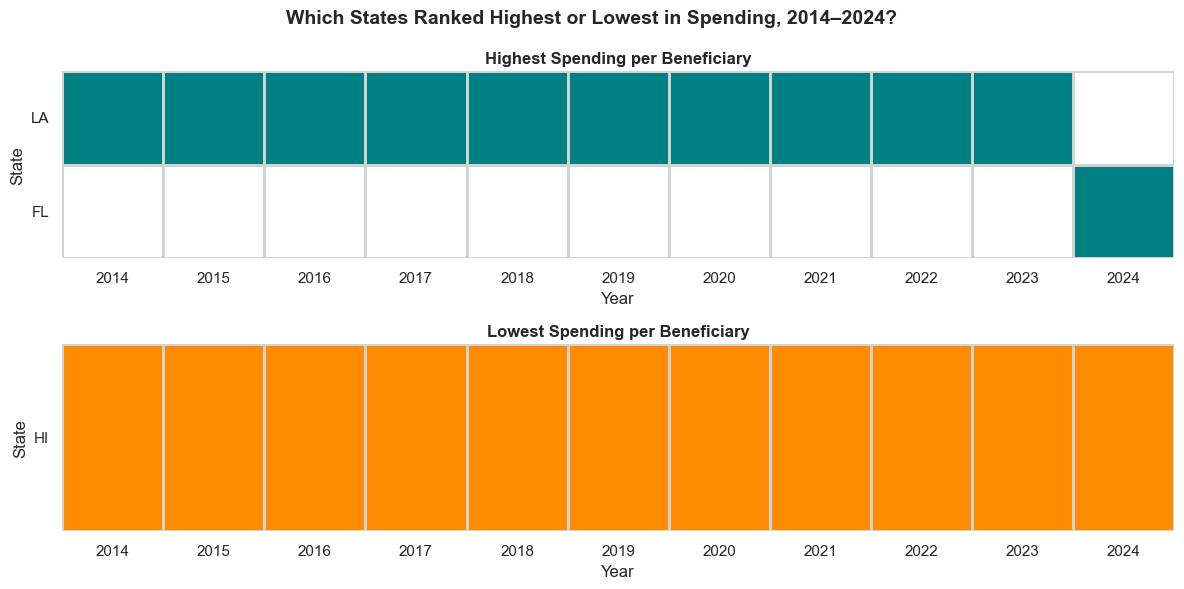

In [5]:
# Rank spending within each year
ranks = state_df.groupby("year")["spend_pc_std"].rank(
    method="min", ascending=False
)
lowest_ranks = state_df.groupby("year")["spend_pc_std"].rank(
    method="min", ascending=True
)

highest = state_df[ranks == 1]
lowest = state_df[lowest_ranks == 1]

# Visualization

fig, axes = plt.subplots(2, 1, figsize=(12, 6))

for ax, data, title, color in [
    (axes[0], highest, "Highest Spending per Beneficiary", "teal"),
    (axes[1], lowest, "Lowest Spending per Beneficiary", "darkorange")
]:
   
    table = pd.crosstab(data["name"], data["year"]).reindex(
        columns=sorted(state_df["year"].unique()), fill_value=0
    )

    table = table.loc[
        table.sum(axis=1).sort_values(ascending=False).index
    ]

    sns.heatmap(
        table, cmap=["white", color], vmin=0, vmax=1,
        linewidths=1, linecolor="lightgray",
        cbar=False, ax=ax
    )

    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Year")
    ax.set_ylabel("State")
    ax.tick_params(axis="both", rotation=0)

fig.suptitle(
    "Which States Ranked Highest or Lowest in Spending, 2014–2024?",
    fontsize=14, fontweight="bold"
)

plt.tight_layout()
plt.show()

### Insight:
**Louisiana had the highest standardized spending per beneficiary** from 2014–2023, with Florida taking the highest position in 2024; **Hawaii had the lowest spending** in all 11 years.

## 5. Correlation between Medicare Spending and Hospital Use
Plotting county spending against inpatient stays, readmissions and ED visits

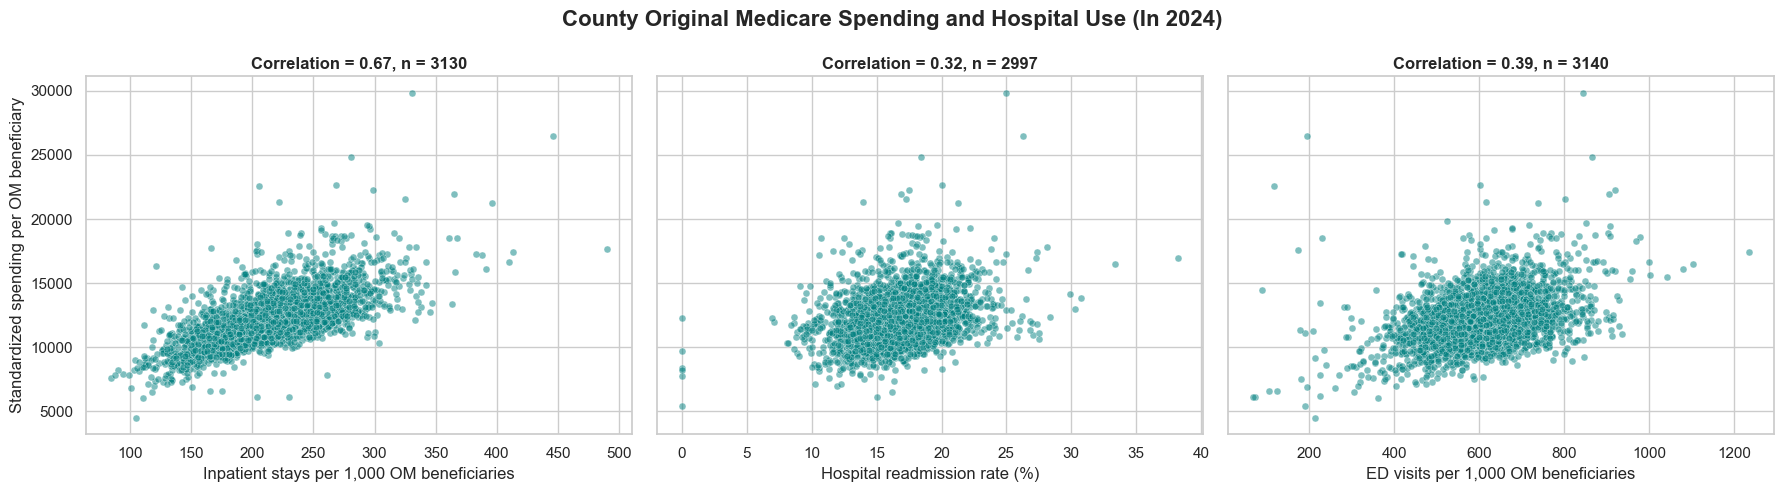

,Hospital-use measure,Correlation,Counties included
0,"Inpatient stays per 1,000 OM beneficiaries",0.666,3130
1,Hospital readmission rate (%),0.318,2997
2,"ED visits per 1,000 OM beneficiaries",0.390,3140


In [6]:
# Select 2024 and exclude unknown county locations
county_2024 = county_df[county_df["year"] == 2024].copy()

county_2024 = county_2024[
    ~county_2024["name"].str.endswith("-UNKNOWN", na=False)
]

# Define hospital-use measures and labels
measures = [
    ("ip_stays_per_1000", "Inpatient stays per 1,000 OM beneficiaries"),
    ("readmit_rate_pct", "Hospital readmission rate (%)"),
    ("ed_visits_per_1000", "ED visits per 1,000 OM beneficiaries")
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
correlation_rows = []

for ax, (variable, label) in zip(axes, measures):

 # Exclude missing values only for the current comparison
    pairs = county_2024.dropna(subset=["spend_pc_std", variable])

# Calculate correlation
    correlation = pairs["spend_pc_std"].corr(pairs[variable])

# Visualization
    sns.scatterplot(
        data=pairs,
        x=variable,
        y="spend_pc_std",
        color="teal",
        alpha=0.5,
        s=25,
        ax=ax
    )

    ax.set_title(
        f"Correlation = {correlation:.2f}, n = {len(pairs)}",
        fontweight="bold"
    )
    ax.set_xlabel(label)
    ax.set_ylabel("")

 # Save the correlation and count of counties
    correlation_rows.append({
        "Hospital-use measure": label,
        "Correlation": correlation,
        "Counties included": len(pairs)
    })

axes[0].set_ylabel("Standardized spending per OM beneficiary")

fig.suptitle(
    "County Original Medicare Spending and Hospital Use (In 2024)",
    fontsize=16, fontweight="bold"
)

plt.tight_layout()
plt.show()

display(pd.DataFrame(correlation_rows).round(3))

### Graph Interpretation

1. **Counties with more inpatient stays tend to have higher standardized spending per Original Medicare beneficiary.** This is the clearest relationship in the graph, with a correlation of 0.67 across 3,130 counties. However, total spending includes inpatient payments, so part of this association reflects hospital care being a component of spending.

2. **The relationships with readmissions and emergency department visits are weaker.** Spending has a positive correlation of 0.32 with readmission rates and 0.39 with ED visits. The wider scatter in these panels shows that counties with similar readmission rates or ED use can have quite different spending levels. These measures therefore capture only part of the geographic variation in spending.

3. A few counties have unusually high spending, and these observations may influence the correlations. The number of counties also differs across comparisons because each plot excludes counties missing either spending or the relevant hospital-use measure: 2,997 counties are included for readmissions and 3,140 for ED visits.

4. Overall, the results support a positive association between spending and hospital use, particularly inpatient stays. They do not establish causation or show that higher spending means poorer quality or less efficient care.

## 6. Forecasting and Residual Plots
Comparing the accuracy of 2-years and 3-years moving average forecast models

Historical forecasts and actual spending:


,year,spend_pc_std,forecast_2yr,forecast_3yr
3,2017,9753.0,9494.0,9393.00
4,2018,10093.0,9643.0,9580.33
5,2019,10404.0,9923.0,9793.00
6,2020,9931.0,10248.5,10083.33
7,2021,10696.0,10167.5,10142.67
8,2022,11087.0,10313.5,10343.67
9,2023,11886.0,10891.5,10571.33
10,2024,12553.0,11486.5,11223.00


Historical forecast accuracy:


,Method,MAD,MAPE (%)
0,forecast_2yr,608.81,5.46
1,forecast_3yr,697.17,6.21


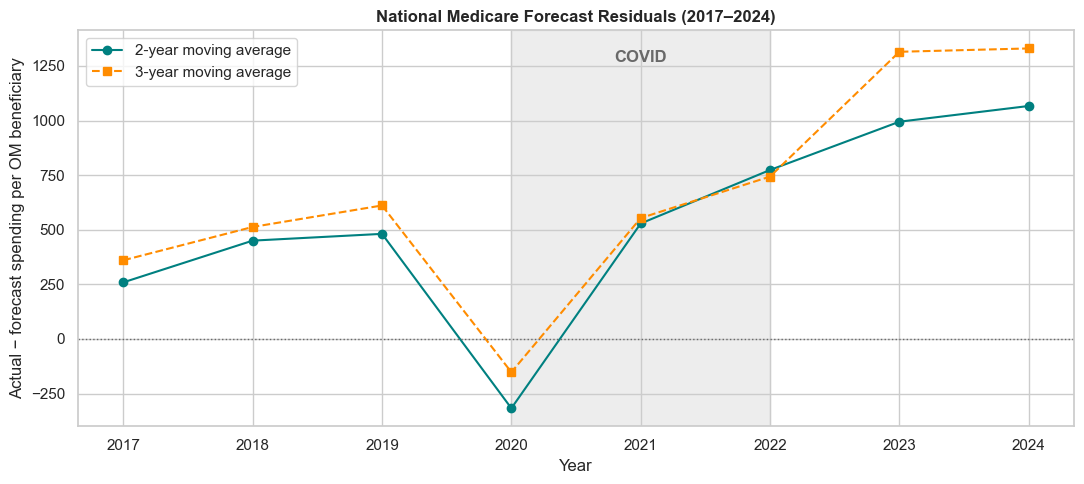

In [7]:
# Sort national spending by year
forecast_df = national_df[
    ["year", "spend_pc_std"]
].sort_values("year").copy()

# Predict each year using the previous 2 or 3 years
forecast_df["forecast_2yr"] = (
    forecast_df["spend_pc_std"].shift(1).rolling(2).mean()
)

forecast_df["forecast_3yr"] = (
    forecast_df["spend_pc_std"].shift(1).rolling(3).mean()
)

# Compare both methods using the same years (2017–2024)
comparison = forecast_df.dropna(
    subset=["spend_pc_std", "forecast_2yr", "forecast_3yr"]
).copy()

accuracy_rows = []

for method in ["forecast_2yr", "forecast_3yr"]:
    # Calculate the absolute difference between actual and forecast spending
    absolute_error = abs(
        comparison["spend_pc_std"] - comparison[method]
    )

    # Mean absolute error
    mad = absolute_error.mean()

    # Mean absolute percentage error
    mape = (
        absolute_error / comparison["spend_pc_std"] * 100
    ).mean()

    accuracy_rows.append({
        "Method": method,
        "MAD": mad,
        "MAPE (%)": mape
    })

print("Historical forecasts and actual spending:")
display(comparison.round(2))

print("Historical forecast accuracy:")
display(pd.DataFrame(accuracy_rows).round(2))

# Calculate forecast residuals using the same comparison years
residual_df = comparison.copy()

residual_df["residual_2yr"] = (
    residual_df["spend_pc_std"] - residual_df["forecast_2yr"]
)

residual_df["residual_3yr"] = (
    residual_df["spend_pc_std"] - residual_df["forecast_3yr"]
)

fig, ax = plt.subplots(figsize=(11, 5))

# Visualization
ax.plot(
    residual_df["year"], residual_df["residual_2yr"],
    marker="o", color="teal", label="2-year moving average"
)

ax.plot(
    residual_df["year"], residual_df["residual_3yr"],
    marker="s", linestyle="--",
    color="darkorange", label="3-year moving average"
)

# Zero represents a forecast that exactly matches actual spending
ax.axhline(
    0, color="dimgray", linestyle=":", linewidth=1
)

# Highlight the selected COVID period
ax.axvspan(
    2020, 2022, color="lightgray", alpha=0.4, zorder=0
)
ax.text(
    2021, 0.95, "COVID",
    transform=ax.get_xaxis_transform(),
    ha="center", va="top",
    color="dimgray", fontweight="bold"
)
ax.set_title(
    "National Medicare Forecast Residuals (2017–2024)",
    fontweight="bold"
)
ax.set_xlabel("Year")
ax.set_ylabel("Actual − forecast spending per OM beneficiary")
ax.set_xticks(residual_df["year"])
ax.legend()

plt.tight_layout()
plt.show()

## Graph Interpretation
1. The **2-year moving average performed better overall** during 2017–2024. Its MAD was 608.81 per beneficiary, compared with $697.17 for the 3-year method. Its MAPE was also lower.

2. Both methods generally underestimated spending as it increased over time. In 2024, actual standardized spending was $12,553 per OM beneficiary while the 2-year forecast was 11,486.50 and the 3-year forecast was $11,223. Moving averages lag behind a rising trend because they rely on earlier, lower spending values.

3. The pattern reversed in 2020, when spending declined and both methods overestimated it. This illustrates their limited ability to anticipate sudden changes. Although the 2-year method was more accurate overall, it was not better in every individual year.


## 7. Hospital Use in Urban and Rural Counties: 2014–2019 vs 2023–2024

Compare average hospital use across urban and rural counties. The comparison excludes the selected pandemic disruption period, 2020–2022.

,rural_urban,period,ip_stays_per_1000,readmit_rate_pct,ed_visits_per_1000
0,Rural,Post: 2023–2024,212.12,16.44,612.14
1,Rural,Pre: 2014–2019,264.94,16.38,691.05
2,Urban,Post: 2023–2024,221.28,17.41,590.32
3,Urban,Pre: 2014–2019,269.02,17.27,680.29


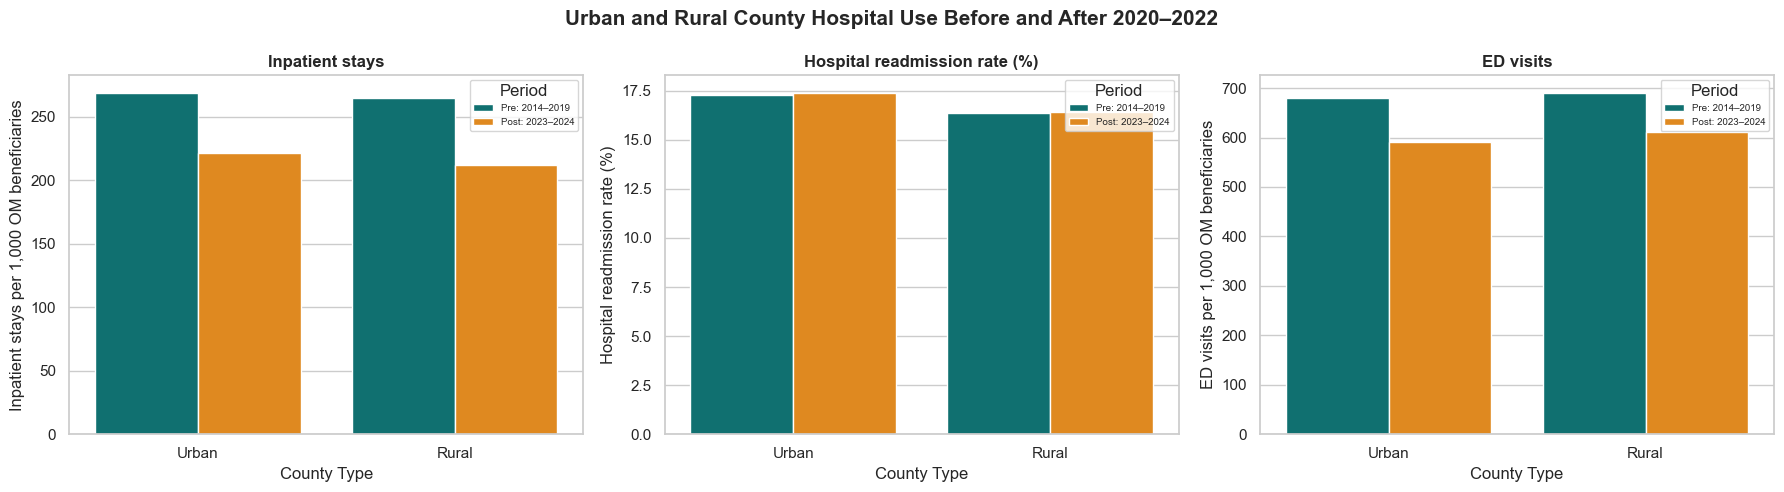

In [8]:
# Select comparison years and counties with an Urban/Rural type
county_compare = county_df[
    ((county_df["year"] <= 2019) | (county_df["year"] >= 2023)) &
    county_df["rural_urban"].isin(["Urban", "Rural"]) &
    ~county_df["name"].str.endswith("-UNKNOWN", na=False)
].copy()

# Label periods before and after the COVID pandemic
county_compare["period"] = county_compare["year"].apply(
    lambda year: "Pre: 2014–2019" if year <= 2019
    else "Post: 2023–2024"
)

hospital_measures = [
    "ip_stays_per_1000",
    "readmit_rate_pct",
    "ed_visits_per_1000"
]

# Average each county's hospital use within each period
county_period = county_compare.groupby(
    ["fips", "rural_urban", "period"]
)[hospital_measures].mean().reset_index()

hospital_summary = county_period.groupby(
    ["rural_urban", "period"]
)[hospital_measures].mean().reset_index()

display(hospital_summary.round(2))

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

labels = [
    "Inpatient stays per 1,000 OM beneficiaries",
    "Hospital readmission rate (%)",
    "ED visits per 1,000 OM beneficiaries"
]

for ax, variable, label in zip(axes, hospital_measures, labels):
    sns.barplot(
        data=hospital_summary,
        x="rural_urban",
        y=variable,
        hue="period",
        order=["Urban", "Rural"],
        hue_order=["Pre: 2014–2019", "Post: 2023–2024"],
        palette=["teal", "darkorange"],
        errorbar=None,
        ax=ax
    )

    ax.set_xlabel("County Type")
    ax.set_ylabel(label)
    ax.set_title(label.split(" per ")[0], fontweight="bold")
    ax.legend(title="Period", fontsize=7)

fig.suptitle(
    "Urban and Rural County Hospital Use Before and After 2020–2022",
    fontsize=15, fontweight="bold"
)

plt.tight_layout()
plt.show()

## Graph Interpretation

1. **Average inpatient stays and ED visits were lower in 2023–2024 than in 2014–2019 for both urban and rural counties.** Urban counties had slightly more inpatient stays in both periods, while rural counties had more ED visits.

2. **Readmission rates changed much less than inpatient stays or ED visits.** Urban counties had higher readmission rates than rural counties in both periods, with little change between periods. This indicates that fewer hospital stays did not necessarily coincide with a comparable reduction in the readmission rate.

**Notes:** We excluded 2020–2022 to compare hospital use before the pandemic with use after the selected pandemic disruption period. This avoids combining those disruption years with the later comparison period. 

## 8. Geographic Variation in Original Medicare Spending by State (2024)

Map standardized spending per Original Medicare beneficiary across states and DC

In [11]:
# Select states for 2024
state_map = state_df[state_df["year"] == 2024].copy()

# Use state abbreviations to locate each state on map
fig = px.choropleth(
    state_map,
    locations="name",
    locationmode="USA-states",
    scope="usa",
    color="spend_pc_std",
    color_continuous_scale="YlOrRd",
    hover_name="name",
    hover_data={
        "spend_pc_std": ":,.0f",
        "benes_om": ":,.0f"
    },
    labels={
        "spend_pc_std": "Spending per OM beneficiary",
        "benes_om": "OM beneficiaries"
    },
    title="Standardized Original Medicare Spending by State (In 2024)"
)

fig.update_layout(
    height=600,
    margin=dict(l=20, r=20, t=60, b=20)
)

fig.show()

## Graph Interpretation

1. Standardized spending per Original Medicare beneficiary varies substantially across states. Florida has the highest spending at $14,680, while Hawaii has the lowest at $8,622—a difference of $6,058 per beneficiary.

2. **Higher spending is concentrated in several southern states**, including Florida, Oklahoma, Mississippi, Louisiana, and Texas. Lower spending appears in Hawaii, Alaska, Oregon, Vermont, and Montana. However, the map also shows variation within broad regions, so geography alone does not explain the differences.

3. Because spending is standardized for geographic payment-rate differences, the darker shades cannot simply be attributed to higher local payment rates. Differences may reflect service use, beneficiary health needs, and other factors that this map does not separate. Higher spending therefore does not, by itself, indicate better care or greater inefficiency.